[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/energy-system-modeling/blob/main/notebooks/capstone/texas_multi_city_buildout.ipynb)

# A multi-city Texas capacity buildout
## REE 4301 / IE 5300 / IE 6301 — Energy Systems Modeling
### Team assignment. Modules 2 and 3, culminating.

You have built a 1-node model (temporal only) and a 3-node model (spatial). This is where they become a system: named Texas load centres with real demand shares, real distances, a fuel network feeding the thermal plants, and more than one planning period.

**The three stages:**

| Stage | What you add | The question it answers |
|---|---|---|
| 1 | Named Texas hubs, real demand and distances | Where does capacity get built when land and load are in different places? |
| 2 | Gas and coal sub-networks feeding generators | What does it cost to *deliver* fuel, and where does that bind? |
| 3 | Multiple planning periods | What gets built first, and what does the answer depend on? |

Each stage runs on its own. Get Stage 1 solving before you start Stage 2.

**The structural model for this notebook is the Spring 2026 student reference project `Texas_Grid_Expansion_PyPSA.ipynb`.** You are welcome to read it. Be warned that it contains four unit and weighting errors, all of which are corrected here and two of which you will measure in Stage 2 — finding them is part of what this assignment teaches.


In [1]:
# --- setup: generated by tools/sync_setup_cells.py -- do not edit here, edit that
# The same cell in every notebook in this series. It installs what Colab does
# not have, fetches the repository so that data/ and src/ are present, and moves
# into this notebook's own folder so the relative paths below resolve.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sear-labs/energy-system-modeling"
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1]
NOTEBOOK_DIR = "notebooks/capstone"

# Pinned, per Part 1 rule 3: an unpinned install will one day pull a major
# version with a changed API and either break or silently alter the answer.
PINS = ["gurobipy>=11,<14", "highspy>=1.11,<2", "pypsa>=1.3,<2"]

if "google.colab" in sys.modules:
    if PINS:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PINS], check=True)
    # An ABSOLUTE base, so re-running this cell is safe. Colab's "Run all" is
    # commonly run twice, and a relative check would look for the clone inside
    # the folder it had already moved into -- cloning a second copy nested one
    # level down, then working from the wrong one.
    BASE = Path("/content") if Path("/content").is_dir() else Path.home()
    REPO_DIR = BASE / REPO_NAME
    if not REPO_DIR.exists():
        cloned = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
            capture_output=True, text=True)
        if cloned.returncode != 0:
            raise SystemExit(
                "Could not clone " + REPO_URL + "\n"
                + (cloned.stderr or "").strip() + "\n\n"
                "If that says 'not found', the repository is still private.\n"
                "A raw file URL fails the same way, so there is no way around\n"
                "it: it has to be public before a student can run this.")
    os.chdir(REPO_DIR / NOTEBOOK_DIR)
elif Path.cwd().name != Path(NOTEBOOK_DIR).name:
    raise SystemExit(
        "Run this notebook from its own folder (" + NOTEBOOK_DIR + "),\n"
        "so that ../../src and ../../data resolve.")

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))
print("working directory:", Path.cwd().name)

# --- end generated setup; the notebook's own imports follow ---


import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.2f}'.format)

HOURS = 24                     # one representative day
PERIODS = [2030, 2040, 2050]
DISCOUNT = 0.07                # WACC


def crf(rate, years):
    """Capital recovery factor — annualises an overnight capital cost."""
    return rate * (1 + rate) ** years / ((1 + rate) ** years - 1)


def daily_capital(capex_per_mw, lifetime_years):
    """$/MW overnight -> $/MW/day.

    Each period in this model is one 24-hour representative day, so every
    cost in the objective has to be on a per-day basis.  Mixing $/yr capital
    with $/day operating is the most common way to get a capacity-expansion
    answer that is wrong by three orders of magnitude.
    """
    return capex_per_mw * crf(DISCOUNT, lifetime_years) / 365.0


print(f'CRF(7%, 30 yr) = {crf(0.07, 30):.4f}')
print(f'CRF(7%, 15 yr) = {crf(0.07, 15):.4f}')


working directory: capstone


CRF(7%, 30 yr) = 0.0806
CRF(7%, 15 yr) = 0.1098


---

### Choosing a solver



This notebook defaults to **HiGHS**, and the table below is why. `pip install gurobipy` ships a restricted licence that needs no registration at all, but it solves models only up to **2,000 variables and 2,000 constraints** — and two of the three stages here are past that. Switching costs nothing: HiGHS and Gurobi agree to sixteen significant figures on every model in this notebook.



That ceiling arrives sooner than you would think. Measured sizes for the models in this course:



| model | variables | constraints | restricted licence |

|---|---|---|---|

| 1-node, 24 hours | 123 | 291 | fits |

| SB6 Stage 1 | 766 | 1,837 | fits |

| SB6 Stage 2 | 886 | 2,172 | too big |

| SB6 Stage 3 | 2,614 | 6,444 | too big |

| TX-123BT, 24 hours | 16,080 | 38,304 | 19x over |



When you exceed it, Gurobi returns *"Model too large for size-limited license"*. Two ways past it:



**In class — switch to HiGHS.** Open source, no licence, no size limit. Uncomment the `SOLVER` line below. There is no accuracy cost: HiGHS and Gurobi agree to sixteen significant figures on every model here. The speed cost is real only when the problem is large — measured on a 1-node model, HiGHS is *marginally faster* at 24 hours, identical at one week, and about **12x slower** on a full 8,760-hour year (22 s against 1.8 s). On a mixed-integer unit-commitment problem with 2,880 binary variables the gap was only **1.8x**.



**For homework — get an academic licence.** A free Web License Service (WLS) key from gurobi.com works in Colab with **no licence file**: paste the three values into `WLS` below. Build the environment **once** and reuse it — constructing a new one for every solve re-authenticates each time and will exhaust a WLS session partway through a scenario sweep.



In [2]:
SOLVER = 'highs'      # open source, no licence, no size cap - and two of the
                      # three stages below are past Gurobi's free limit

# SOLVER = 'gurobi'   # <-- uncomment if you have an academic WLS key



# For homework: paste your academic Web License Service key here.

# Leave it empty and Gurobi falls back to its restricted licence.

WLS = {}   # {'WLSACCESSID': '...', 'WLSSECRET': '...', 'LICENSEID': 000000}



ENV = None

if SOLVER == 'gurobi' and WLS:

    import gurobipy as gp

    ENV = gp.Env(params=WLS)     # ONE environment, reused by every solve



print(f'solver: {SOLVER}'

      + ('  (academic WLS licence)' if ENV else '  (default licence)'))



solver: highs  (default licence)


---
## Stage 1 — From the 3-node template to named Texas hubs

The 3-node model called its buses A, B and C. Naming them changes the assignment: once a bus is *Houston*, its demand, its resources and its distance to everywhere else are facts you have to source rather than choose.

### Demand

The hub shares below are the real ERCOT weather-zone shares of daily energy, computed from the TX-123BT synthetic Texas system's nodal load for 20 January 2021 — a normal winter day. (Same dataset the GRAD-N assignment imports.) North Central, which is Dallas–Fort Worth, is 32% of state energy; the Coast, which is Houston, is 26%.

> **Requirement.** You must state each node's assumed demand and available resources **with a citation**. The values here are a defensible starting point, not the only one. If you use a different source — ERCOT's own hourly load-by-weather-zone archive, for instance — say so and say why.


In [3]:
# (latitude, longitude) of each hub
HUBS = {
    'Dallas-Fort Worth': (32.7767, -96.7970),
    'Houston':           (29.7604, -95.3698),
    'San Antonio':       (29.4241, -98.4936),
    'Austin':            (30.2672, -97.7431),
    'West Texas':        (31.9973, -102.0779),
}

# Share of statewide daily energy, from real ERCOT weather-zone data
# (TX-123BT nodal load, 20 January 2021).  The eight ERCOT weather zones
# carry, in order: NCENT 32.1%, COAST 26.1%, SCENT 16.2%, FWEST 9.6%,
# SOUTH 7.1%, EAST 3.8%, WEST 3.1%, NORTH 2.0%.
#
# Mapping eight zones onto five hubs is a modelling decision, not a fact.
# The one used here, which you may change if you justify it:
#   NCENT + NORTH        -> Dallas-Fort Worth
#   COAST + EAST         -> Houston
#   SCENT x 0.6 + SOUTH  -> San Antonio
#   SCENT x 0.4          -> Austin
#   FWEST + WEST         -> West Texas
HUB_SHARE = {
    'Dallas-Fort Worth': 0.341,
    'Houston':           0.299,
    'San Antonio':       0.168,
    'Austin':            0.065,
    'West Texas':        0.127,
}
assert abs(sum(HUB_SHARE.values()) - 1.0) < 1e-9, sum(HUB_SHARE.values())

PEAK_2030_MW = 45_000.0        # statewide winter peak, ERCOT-scale
GROWTH = {2030: 1.00, 2040: 1.20, 2050: 1.44}   # +20% per decade

for hub, share in HUB_SHARE.items():
    print(f'  {hub:20s} {share:5.1%}  ->  {PEAK_2030_MW*share:8,.0f} MW peak in 2030')


  Dallas-Fort Worth    34.1%  ->    15,345 MW peak in 2030
  Houston              29.9%  ->    13,455 MW peak in 2030
  San Antonio          16.8%  ->     7,560 MW peak in 2030
  Austin                6.5%  ->     2,925 MW peak in 2030
  West Texas           12.7%  ->     5,715 MW peak in 2030


### Distance, and why it belongs in the cost

Transmission capital scales with length. If every corridor costs the same regardless of distance, the solver has no reason to prefer a short interconnection over a long one, and the spatial answer is arbitrary.

Great-circle distance between the hub coordinates is close enough for a planning model, and it is a real number you can defend. A right-of-way does not follow a great circle, so this understates route length — say so.


In [4]:
def haversine_km(a, b):
    """Great-circle distance between two (lat, lon) points, in km."""
    R = 6371.0
    lat1, lat2 = np.radians(a[0]), np.radians(b[0])
    dlat = lat2 - lat1
    dlon = np.radians(b[1] - a[1])
    h = (np.sin(dlat / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(h))


CORRIDORS = [
    ('West Texas', 'Dallas-Fort Worth'), ('West Texas', 'Austin'),
    ('Dallas-Fort Worth', 'Houston'),    ('Dallas-Fort Worth', 'Austin'),
    ('Houston', 'Austin'),               ('Austin', 'San Antonio'),
    ('Houston', 'San Antonio'),
]
LINE_CAPEX_PER_MW_KM = 1200.0   # $/MW-km, 345 kV double circuit
LINE_LIFE = 40

for a, b in CORRIDORS:
    km = haversine_km(HUBS[a], HUBS[b])
    daily = daily_capital(LINE_CAPEX_PER_MW_KM * km, LINE_LIFE)
    print(f'  {a:20s} - {b:20s} {km:6.0f} km   ${daily:7.2f} /MW/day')


  West Texas           - Dallas-Fort Worth       503 km   $ 124.12 /MW/day
  West Texas           - Austin                  455 km   $ 112.25 /MW/day
  Dallas-Fort Worth    - Houston                 362 km   $  89.22 /MW/day
  Dallas-Fort Worth    - Austin                  293 km   $  72.28 /MW/day
  Houston              - Austin                  235 km   $  58.04 /MW/day
  Austin               - San Antonio             118 km   $  29.21 /MW/day
  Houston              - San Antonio             304 km   $  75.05 /MW/day


### Resource limits — the constraint that makes a spatial model mean anything

This is the single most important line of modelling judgement in Stage 1.

If you let the solver build unlimited solar and wind at every hub, it will build them locally at every hub, no corridor will ever bind, and the model will report that transmission does not matter. That is not a finding — it is a consequence of forgetting that **land is a resource and it is not where the load is**.

`p_nom_max` per hub is how you express that. The numbers below are order-of-magnitude and are stated as assumptions, not facts. Changing them is one of the sensitivities Stage 3 asks for.


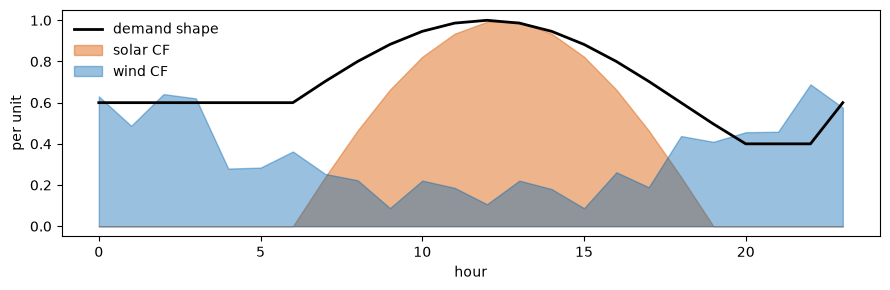

In [5]:
WIND_MAX = {'West Texas': 22_000, 'San Antonio': 4_000,
            'Dallas-Fort Worth': 3_000}
SOLAR_MAX = {'West Texas': 18_000, 'San Antonio': 4_000,
             'Dallas-Fort Worth': 4_000, 'Austin': 2_000, 'Houston': 3_000}


def profiles(seed=42):
    """A 24-hour demand shape and solar/wind capacity factors.

    Placeholders.  Replace them with the profiles from your own
    Mini-Project 2 run, or with a real ERCOT day, before you submit -
    a sine wave is not a load shape and the grader will look.
    """
    h = np.arange(HOURS)
    shape = np.clip(
        0.60 + 0.40 * np.sin(np.pi * (h - 6) / 12) * ((h >= 6) & (h <= 22)),
        0.4, 1.0)
    shape = shape / shape.max()
    solar = np.zeros(HOURS)
    for k in range(6, 19):
        solar[k] = np.sin(np.pi * (k - 6) / 13)
    rng = np.random.default_rng(seed)
    wind = np.clip(0.35 + 0.25 * np.cos(2 * np.pi * h / 24)
                   + 0.10 * rng.normal(0, 1, HOURS), 0.05, 0.85)
    return shape, np.clip(solar, 0, 1), wind


demand_shape, solar_cf, wind_cf = profiles()
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(demand_shape, label='demand shape', color='k', lw=2)
ax.fill_between(range(HOURS), solar_cf, alpha=0.5, color='#DE6B1A',
                label='solar CF')
ax.fill_between(range(HOURS), wind_cf, alpha=0.4, color='#0064B1',
                label='wind CF')
ax.set_xlabel('hour'); ax.set_ylabel('per unit'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()


In [6]:
# Cited cost basis: NREL ATB 2024 (capital, O&M, lifetimes),
# EIA 2023 (fuel prices and heat contents).
GAS_PRICE_MMBTU = 2.50 / 1.036      # $2.50/Mcf over 1.036 MMBtu/Mcf
COAL_PRICE_MMBTU = 20.0 / 13.0      # $20/ton Texas lignite, 13 MMBtu/ton
GAS_HEAT_RATE = 6.4                 # MMBtu per MWh-e, modern CCGT
COAL_HEAT_RATE = 10.0               # MMBtu per MWh-e, legacy unit
GAS_VOM, COAL_VOM = 3.50, 4.50      # $/MWh-e

print(f'gas  ${GAS_PRICE_MMBTU:.3f}/MMBtu  ->  ${GAS_PRICE_MMBTU*GAS_HEAT_RATE + GAS_VOM:.2f}/MWh-e all in')
print(f'coal ${COAL_PRICE_MMBTU:.3f}/MMBtu  ->  ${COAL_PRICE_MMBTU*COAL_HEAT_RATE + COAL_VOM:.2f}/MWh-e all in')


gas  $2.413/MMBtu  ->  $18.94/MWh-e all in
coal $1.538/MMBtu  ->  $19.88/MWh-e all in


---
## Stage 1, one component at a time

We are going to type this network out step by step. That is longer than wrapping it in a function, and it is deliberate: **every line below is a modelling decision**, and you should see each one before it disappears into a `build()` call. Once you have seen them, we will wrap them - at the bottom, where the wrapping belongs.

Read the markdown above each cell before you run it. If you run the whole notebook at once you will get the right answer and learn nothing.


### Step 1 - the network, and what a snapshot costs you

A **snapshot** is one time step the model solves. We use 24: one representative day, which then stands in for a whole year.

That substitution needs care. The day is weighted by 365 so that the fuel bill is a *year* of fuel and can be compared against a *year* of capital charge. Get this weighting wrong and you are setting one day of fuel against a year of capital - the model then builds almost nothing, burns gas forever, and hands you an answer that looks entirely plausible.


In [7]:
n1 = pypsa.Network()

# Stage 1 is a single investment period; Stage 3 adds the rest.
periods = PERIODS[:1]
snapshots = pd.MultiIndex.from_product(
    [periods, range(HOURS)], names=['period', 'timestep'])
n1.set_investment_periods(periods=periods)
n1.set_snapshots(snapshots)

# one representative day standing for a year: 24 h x 365 = 8,760 h
n1.investment_period_weightings['objective'] = 365.0
n1.investment_period_weightings['years'] = 10.0

print(f'{len(n1.snapshots)} snapshots, {len(periods)} investment period')


C:\Users\jonesec\dev\venvs\esm\Lib\site-packages\pypsa\network\io.py:2082: FutureWarning: pandas infers the `str` dtype for string data since its version 3.0. PyPSA still converts it back to numpy object dtype on import, but will keep it from PyPSA 2.0 on. Set `pypsa.options.api.legacy_string_dtype` explicitly to suppress this warning.
  new_static = _coerce_string_dtypes(new_static)
INFO:pypsa.network.index:Repeating time-series for each investment period and converting snapshots to a pandas.MultiIndex.


24 snapshots, 1 investment period


### Step 2 - carriers

A **carrier** labels what kind of energy or material something moves. PyPSA does not need them in order to solve, but every grouped result you print later - capacity by technology, energy by fuel - groups on this column. Declaring them now is what makes the results readable later.


In [8]:
for c in ('AC', 'wind', 'solar', 'battery', 'gas', 'coal',
          'gas supply', 'coal supply'):
    n1.add('Carrier', c)

print(list(n1.carriers.index))


['AC', 'wind', 'solar', 'battery', 'gas', 'coal', 'gas supply', 'coal supply']


### Step 3 - the hubs

One **Bus** per city. A bus is a place where power balances: everything arriving equals everything leaving, in every snapshot. That one equation per bus per hour is the backbone of the entire model - it is the same `Bus-nodal_balance` you met in Module 0, just repeated five times.


In [9]:
for hub in HUBS:
    n1.add('Bus', hub, carrier='AC')

print(f'{len(n1.buses)} hubs: ' + ', '.join(n1.buses.index))


5 hubs: Dallas-Fort Worth, Houston, San Antonio, Austin, West Texas


### Step 4 - the corridors between them

A **Line** is AC transmission. Three of the arguments below are worth stopping on:

- **`x=0.0001 * km`** - reactance grows with length. This is what makes power split between parallel paths by physics rather than by the solver's preference, and it is the whole difference between a transport model and a power-flow model.
- **`s_nom_min=3000`** - what already exists. The solver may add to the grid but may not tear it down.
- **`capital_cost` scaled by `km`** - a longer line costs more, so distance enters the optimisation instead of sitting in a comment.

`s_nom_max=25_000` is deliberate headroom. A real corridor is limited by *stability*, well below what the wires could thermally carry, and Stage 3 adds that limit separately. If the wire itself were the tighter of the two, the stability limit could never bind and the Stage 3 experiment would silently measure nothing.


In [10]:
for a, b in CORRIDORS:
    km = haversine_km(HUBS[a], HUBS[b])
    n1.add('Line', f'{a[:3].upper()}_{b[:3].upper()}',
           bus0=a, bus1=b, length=km,
           x=0.0001 * km,
           s_nom=3000, s_nom_min=3000, s_nom_max=25_000,
           s_nom_extendable=True,
           capital_cost=daily_capital(
               LINE_CAPEX_PER_MW_KM * km, LINE_LIFE))

cols = ['bus0', 'bus1', 'length', 'x', 's_nom']
print(n1.lines[cols].round(1).to_string())


                      bus0               bus1  length    x    s_nom
name                                                               
WES_DAL         West Texas  Dallas-Fort Worth  503.30 0.10 3,000.00
WES_AUS         West Texas             Austin  455.20 0.00 3,000.00
DAL_HOU  Dallas-Fort Worth            Houston  361.80 0.00 3,000.00
DAL_AUS  Dallas-Fort Worth             Austin  293.10 0.00 3,000.00
HOU_AUS            Houston             Austin  235.40 0.00 3,000.00
AUS_SAN             Austin        San Antonio  118.40 0.00 3,000.00
HOU_SAN            Houston        San Antonio  304.30 0.00 3,000.00


### Step 5 - demand

Each hub takes a share of the state peak, shaped by the same 24-hour profile and grown by period.

`p_set` is a fixed requirement, not a choice: the model must serve it in every hour or the problem is infeasible. That is why an unserved-energy generator is a genuine modelling device rather than a cheat - without one, a model that cannot cope simply refuses to solve, and tells you nothing at all about how badly it fell short.


In [11]:
shape, solar_cf, wind_cf = profiles()

for hub, share in HUB_SHARE.items():
    series = np.concatenate(
        [shape * PEAK_2030_MW * share * GROWTH[p] for p in periods])
    n1.add('Load', f'{hub}_demand', bus=hub,
           p_set=pd.Series(series, index=snapshots))

peak = n1.loads_t.p_set.sum(axis=1).max()
energy = n1.loads_t.p_set.sum().sum()
print(f'coincident peak {peak:,.0f} MW')
print(f'daily energy    {energy:,.0f} MWh')


coincident peak 45,000 MW
daily energy    753,065 MWh


### Step 6 - wind and solar

Two arguments carry the whole meaning here:

- **`p_nom_extendable=True`** - capacity is a *decision*, not an input. This single argument is what turns a dispatch model into a capacity-expansion model.
- **`p_nom_max`** - how much can physically be built at that hub. Without it the model will cheerfully build 200 GW of wind in San Antonio, and the answer will be arithmetically correct and completely useless.

`p_max_pu` is the hourly capacity factor: the *fraction* of whatever gets built that is actually available in each hour.


In [12]:
solar_ts = pd.Series(np.tile(solar_cf, len(periods)), index=snapshots)
wind_ts = pd.Series(np.tile(wind_cf, len(periods)), index=snapshots)

for hub, cap in WIND_MAX.items():
    n1.add('Generator', f'{hub}_wind', bus=hub, carrier='wind',
           p_nom_extendable=True, p_nom_max=cap, p_max_pu=wind_ts,
           capital_cost=daily_capital(1_300_000, 30), marginal_cost=0.0)

for hub, cap in SOLAR_MAX.items():
    n1.add('Generator', f'{hub}_solar', bus=hub, carrier='solar',
           p_nom_extendable=True, p_nom_max=cap, p_max_pu=solar_ts,
           capital_cost=daily_capital(900_000, 30), marginal_cost=0.0)

print(n1.generators[['bus', 'carrier', 'p_nom_max']].to_string())


                                       bus carrier  p_nom_max
name                                                         
West Texas_wind                 West Texas    wind  22,000.00
San Antonio_wind               San Antonio    wind   4,000.00
Dallas-Fort Worth_wind   Dallas-Fort Worth    wind   3,000.00
West Texas_solar                West Texas   solar  18,000.00
San Antonio_solar              San Antonio   solar   4,000.00
Dallas-Fort Worth_solar  Dallas-Fort Worth   solar   4,000.00
Austin_solar                        Austin   solar   2,000.00
Houston_solar                      Houston   solar   3,000.00


### Step 7 - storage

`max_hours=4` means the energy store is four times the power rating, so a 100 MW battery holds 400 MWh. The 0.927 efficiencies are one-way, so the round trip is 0.927 squared - about 86%.

`cyclic_state_of_charge=True` forces the battery to end the day where it started. Leave it off and the model starts every representative day with a full battery it never had to charge: free energy, 365 times a year.


In [13]:
for hub in HUBS:
    n1.add('StorageUnit', f'{hub}_battery', bus=hub, carrier='battery',
           p_nom_extendable=True, max_hours=4,
           efficiency_store=0.927, efficiency_dispatch=0.927,
           cyclic_state_of_charge=True,
           capital_cost=daily_capital(400_000, 15), marginal_cost=0.001)

rt = 0.927 ** 2
print(f'{len(n1.storage_units)} batteries, 4-hour, {rt:.1%} round trip')


5 batteries, 4-hour, 85.9% round trip


### Step 8 - gas, as a price rather than as a network

In Stage 1 gas is one **Generator** with an all-in marginal cost: fuel plus variable O&M, in dollars per MWh of electricity out. There is no pipeline, no wellhead, no fuel bus. Gas is simply available at Houston at a price.

That is a real and extremely common modelling choice, and it is exactly what Stage 2 takes apart. Notice what it assumes: **unlimited fuel, delivered instantly, at a price that never moves.** In February 2021 all three of those assumptions failed at the same time.


In [14]:
n1.add('Generator', 'Houston_CCGT', bus='Houston', carrier='gas',
       p_nom_extendable=True,
       capital_cost=daily_capital(1_050_000, 30) + 15_300 / 365,
       marginal_cost=GAS_VOM + GAS_PRICE_MMBTU * GAS_HEAT_RATE)

mc = GAS_VOM + GAS_PRICE_MMBTU * GAS_HEAT_RATE
print(f'gas marginal cost ${mc:.2f}/MWh-e')


gas marginal cost $18.94/MWh-e


### Step 9 - solve it

**Predict before you run.** Write down now, in one line each: which technology gets built the most, and which corridor expands first? A number you had no expectation about teaches you nothing when it arrives.


In [15]:
status, condition = n1.optimize(
    solver_name=SOLVER, env=ENV,
    multi_investment_periods=False, log_to_console=False)
assert condition == 'optimal', f'solver returned {status}/{condition}'


C:\Users\jonesec\AppData\Local\Temp\ipykernel_33532\884018102.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n1.optimize(
Index(['WES_DAL', 'WES_AUS', 'DAL_HOU', 'DAL_AUS', 'HOU_AUS', 'AUS_SAN',
       'HOU_SAN'],
      dtype='object', name='name')


INFO:pypsa.optimization.window:Building the multi-period model over a MultiIndex `snapshot`. Opt into the flat representation via `pypsa.options.optimization.model_snapshot_index = 'flat'`.


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.12s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 766 primals, 1837 duals
Objective: 2.32e+07
Solver: highs
Runtime: 0.03s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


In [16]:
# Stages 1 and 2 are single-period, so PyPSA ignores the investment-
# period weighting and the objective is the cost of ONE representative
# day.  Multiply by 365 for an annual figure.
print(f'Stage 1 solved.  daily system cost ${n1.objective:,.0f}'
      f'  (~${n1.objective*365/1e9:,.1f} bn/yr)')
print()
built = n1.generators.p_nom_opt.groupby(n1.generators.carrier).sum()
for carrier, mw in built.sort_values(ascending=False).items():
    print(f'  {carrier:10s} {mw:9,.0f} MW')
print(f'  {"storage":10s} {n1.storage_units.p_nom_opt.sum():9,.0f} MW')
print()
expanded = n1.lines[n1.lines.s_nom_opt > n1.lines.s_nom + 1]
print('corridors the solver chose to expand:')
if len(expanded) == 0:
    print('  none')
for name, r in expanded.iterrows():
    print(f'  {name:10s} {r.bus0:20s} -> {r.bus1:20s} '
          f'{r.s_nom:6,.0f} -> {r.s_nom_opt:7,.0f} MW  ({r.length:.0f} km)')


Stage 1 solved.  daily system cost $23,166,407  (~$8.5 bn/yr)

  solar         23,725 MW
  gas           22,099 MW
  wind           8,152 MW
  storage        3,155 MW

corridors the solver chose to expand:
  DAL_HOU    Dallas-Fort Worth    -> Houston               3,000 ->   4,922 MW  (362 km)
  HOU_AUS    Houston              -> Austin                3,000 ->   5,037 MW  (235 km)
  HOU_SAN    Houston              -> San Antonio           3,000 ->   4,067 MW  (304 km)


---
## Now the streamlined version

You have watched every component go in, one at a time. From here on we need the *same* network several more ways - two fuel-efficiency settings, three stages, a gas-price sweep - and retyping it each time would be both tedious and an excellent way to introduce a difference you did not intend.

**So now we wrap it.** This is the right moment to do that: after you know what is inside, not before. The function below is the nine steps you just ran, plus the Stage 2 and Stage 3 branches, behind a `stage` switch.

The cell after it checks that the wrapper reproduces what you built by hand. That check is not ceremony - it is how you find out that the convenient version and the version you actually understand have quietly drifted apart.


In [17]:
def build(stage=3, fuel_efficiency='correct', gas_price_mmbtu=None):
    """Assemble the SB6 network.

    stage 1 : hubs, transmission, renewables, storage; gas as a simple
              Generator with an all-in marginal cost
    stage 2 : + gas and coal sub-networks, plants become Links
    stage 3 : + multiple investment periods

    fuel_efficiency : 'correct' uses 1/heat_rate.  'thermal' reproduces the
              Spring reference notebook's 3.412/heat_rate so Stage 2 can
              measure what the error does.  Never use 'thermal' for a
              result you intend to report.
    """
    gas_price = (GAS_PRICE_MMBTU if gas_price_mmbtu is None
                 else gas_price_mmbtu)
    n = pypsa.Network()
    periods = PERIODS if stage >= 3 else PERIODS[:1]
    snapshots = pd.MultiIndex.from_product(
        [periods, range(HOURS)], names=['period', 'timestep'])
    n.set_investment_periods(periods=periods)
    n.set_snapshots(snapshots)

    # One 24-hour day stands for a year: 24 snapshots x 365 = 8760 h.
    # The Spring reference weights the day by 8760, which counts 210,240
    # hours per period - 24 years of fuel against one year of capital.
    n.investment_period_weightings['objective'] = 365.0
    n.investment_period_weightings['years'] = 10.0

    for c in ('AC', 'wind', 'solar', 'battery', 'gas', 'coal',
              'gas supply', 'coal supply'):
        n.add('Carrier', c)

    # ---- hubs and corridors --------------------------------------
    for hub in HUBS:
        n.add('Bus', hub, carrier='AC')
    for a, b in CORRIDORS:
        km = haversine_km(HUBS[a], HUBS[b])
        n.add('Line', f'{a[:3].upper()}_{b[:3].upper()}',
              bus0=a, bus1=b, length=km,
              x=0.0001 * km,          # reactance grows with length
              s_nom=3000, s_nom_min=3000, s_nom_max=25_000,
              # headroom on purpose: a real stability limit sits BELOW
              # the thermal rating of the wires - see Stage 3
              s_nom_extendable=True,
              capital_cost=daily_capital(
                  LINE_CAPEX_PER_MW_KM * km, LINE_LIFE))

    # ---- demand ---------------------------------------------------
    shape, solar_cf, wind_cf = profiles()
    for hub, share in HUB_SHARE.items():
        series = np.concatenate(
            [shape * PEAK_2030_MW * share * GROWTH[p] for p in periods])
        n.add('Load', f'{hub}_demand', bus=hub,
              p_set=pd.Series(series, index=snapshots))

    # ---- renewables and storage -----------------------------------
    solar_ts = pd.Series(np.tile(solar_cf, len(periods)), index=snapshots)
    wind_ts = pd.Series(np.tile(wind_cf, len(periods)), index=snapshots)
    for hub, cap in WIND_MAX.items():
        n.add('Generator', f'{hub}_wind', bus=hub, carrier='wind',
              p_nom_extendable=True, p_nom_max=cap, p_max_pu=wind_ts,
              capital_cost=daily_capital(1_300_000, 30), marginal_cost=0.0)
    for hub, cap in SOLAR_MAX.items():
        n.add('Generator', f'{hub}_solar', bus=hub, carrier='solar',
              p_nom_extendable=True, p_nom_max=cap, p_max_pu=solar_ts,
              capital_cost=daily_capital(900_000, 30), marginal_cost=0.0)
    for hub in HUBS:
        n.add('StorageUnit', f'{hub}_battery', bus=hub, carrier='battery',
              p_nom_extendable=True, max_hours=4,
              efficiency_store=0.927, efficiency_dispatch=0.927,
              cyclic_state_of_charge=True,
              capital_cost=daily_capital(400_000, 15), marginal_cost=0.001)

    if stage < 2:
        # Gas as a plain Generator: fuel is a price, not a network.
        n.add('Generator', 'Houston_CCGT', bus='Houston', carrier='gas',
              p_nom_extendable=True,
              capital_cost=daily_capital(1_050_000, 30) + 15_300 / 365,
              marginal_cost=GAS_VOM + gas_price * GAS_HEAT_RATE)
        return n

    # ---- Stage 2: fuel and material sub-networks -------------------
    # Energy on these buses is MMBtu/h, NOT MW.  Every number that
    # crosses between a fuel bus and an AC bus needs a conversion.
    n.add('Bus', 'Permian_gas', carrier='gas')
    n.add('Bus', 'Houston_gas', carrier='gas')
    n.add('Generator', 'Permian_wellhead', bus='Permian_gas',
          carrier='gas supply', p_nom=5e5,
          marginal_cost=gas_price)
    n.add('Link', 'Permian_Houston_pipeline', bus0='Permian_gas',
          bus1='Houston_gas', p_nom=3e5, efficiency=1.0,
          marginal_cost=0.50)          # $/MMBtu transport tariff

    n.add('Bus', 'Lignite_mine', carrier='coal')
    n.add('Bus', 'SanAntonio_coalyard', carrier='coal')
    n.add('Generator', 'Lignite_seam', bus='Lignite_mine',
          carrier='coal supply', p_nom=1e5,
          marginal_cost=COAL_PRICE_MMBTU)
    n.add('Link', 'Lignite_rail', bus0='Lignite_mine',
          bus1='SanAntonio_coalyard', p_nom=5e4, efficiency=1.0,
          marginal_cost=0.75)          # $/MMBtu rail tariff

    # A power plant is a Link from a fuel bus to an AC bus.
    # efficiency = MWh-e out per MMBtu in = 1 / heat_rate.
    # 3.412/heat_rate is the DIMENSIONLESS thermal efficiency and is wrong
    # here by exactly 3.412.  See the Stage 2 experiment below.
    if fuel_efficiency == 'correct':
        eff_gas, eff_coal = 1 / GAS_HEAT_RATE, 1 / COAL_HEAT_RATE
    else:
        eff_gas = 3.412 / GAS_HEAT_RATE
        eff_coal = 3.412 / COAL_HEAT_RATE

    # A Link's p_nom is its bus0 (INPUT) capacity, in MMBtu/h here.
    # $/MW-e figures therefore have to be multiplied by efficiency, and a
    # plant's MW-e rating divided by it.
    n.add('Link', 'Houston_CCGT', bus0='Houston_gas', bus1='Houston',
          carrier='gas', efficiency=eff_gas, p_nom_extendable=True,
          capital_cost=(daily_capital(1_050_000, 30)
                        + 15_300 / 365) * eff_gas,
          marginal_cost=GAS_VOM / GAS_HEAT_RATE)   # $/MMBtu of input
    n.add('Link', 'SanAntonio_coal', bus0='SanAntonio_coalyard',
          bus1='San Antonio', carrier='coal', efficiency=eff_coal,
          p_nom=400.0 / eff_coal,      # a 400 MW-e legacy unit
          p_nom_extendable=False, capital_cost=0.0,   # sunk
          marginal_cost=COAL_VOM / COAL_HEAT_RATE)
    return n


def solve(n, **kw):
    status, condition = n.optimize(
        solver_name=SOLVER, env=ENV,
        multi_investment_periods=len(n.investment_periods) > 1,
        log_to_console=False, **kw)
    if condition != 'optimal':
        raise RuntimeError(f'solver returned {status}/{condition}')
    return n


Same network, same answer - so from here the function is safe to trust:


In [18]:
check = solve(build(stage=1))
rel = abs(check.objective - n1.objective) / n1.objective

print(f'hand-built   ${n1.objective:,.2f}')
print(f'build(1)     ${check.objective:,.2f}')
print(f'relative difference {rel:.2e}')
assert rel < 1e-9, 'the wrapper does not reproduce the hand-built network'
print()
print('the wrapper reproduces the hand-built network exactly.')


INFO:pypsa.network.index:Repeating time-series for each investment period and converting snapshots to a pandas.MultiIndex.


C:\Users\jonesec\AppData\Local\Temp\ipykernel_33532\639906200.py:130: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n.optimize(
Index(['WES_DAL', 'WES_AUS', 'DAL_HOU', 'DAL_AUS', 'HOU_AUS', 'AUS_SAN',
       'HOU_SAN'],
      dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.11s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 766 primals, 1837 duals
Objective: 2.32e+07
Solver: highs
Runtime: 0.03s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


hand-built   $23,166,407.14
build(1)     $23,166,407.14
relative difference 0.00e+00

the wrapper reproduces the hand-built network exactly.


> **Exercise S1.1.** Which corridors expanded, and why those? Relate the answer to `WIND_MAX` and `SOLAR_MAX` — the corridors that expand are the ones that connect buildable resource to load.

> **Exercise S1.2.** Set every hub's `SOLAR_MAX` to 50,000 and re-solve. How much transmission does the solver build now? Explain in one sentence why an unconstrained spatial model is not a spatial model.


---
## Stage 2 — Fuel and material sub-networks

In Stage 1 gas was a price: `marginal_cost = VOM + fuel × heat rate`. That is fine until you want to ask a question about the fuel itself — whether the pipeline binds, what a transport tariff is worth, what happens when the wellhead is constrained.

Stage 2 makes fuel a network:

```
Permian wellhead --pipeline--> Houston gas bus --CCGT--> Houston AC bus
Lignite seam     --rail-----> San Antonio coalyard --plant--> SA AC bus
```

The plants are now **Links**, not Generators: they consume from a fuel bus and deliver to an electrical bus.

### The unit conversion that decides your answer

Everything on a fuel bus is in **MMBtu/h**. Everything on an AC bus is in **MW**. A `Link` between them has an `efficiency` that carries the conversion, and it must be **MWh-e out per MMBtu in**, which is `1 / heat_rate`. For a 6.4 MMBtu/MWh CCGT that is **0.156**.

It is very easy to write `3.412 / heat_rate` instead — 0.533 — because that is the *thermal* efficiency, the dimensionless number you would quote a plant by, and 3.412 MMBtu per MWh is a conversion you use constantly elsewhere. The Spring reference project makes exactly this mistake, in a line whose own comment states the correct value.

Run both and see what it costs you.


In [19]:
runs = {}
for label in ('correct', 'thermal'):
    m = solve(build(stage=2, fuel_efficiency=label))
    runs[label] = m
    eff = m.links.efficiency['Houston_CCGT']
    ccgt_mwe = m.links.p_nom_opt['Houston_CCGT'] * eff
    built = m.generators.p_nom_opt.groupby(m.generators.carrier).sum()
    print(f'--- efficiency convention: {label}   (eff = {eff:.4f})')
    print(f'    daily system cost    ${m.objective:>16,.0f}')
    print(f'    CCGT built           {ccgt_mwe:>12,.0f} MW-e')
    print(f'    wind built           {built.get("wind", 0):>12,.0f} MW')
    print(f'    solar built          {built.get("solar", 0):>12,.0f} MW')
    print(f'    storage built        {m.storage_units.p_nom_opt.sum():>12,.0f} MW')
    print()


INFO:pypsa.network.index:Repeating time-series for each investment period and converting snapshots to a pandas.MultiIndex.


C:\Users\jonesec\AppData\Local\Temp\ipykernel_33532\639906200.py:130: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n.optimize(
Index(['WES_DAL', 'WES_AUS', 'DAL_HOU', 'DAL_AUS', 'HOU_AUS', 'AUS_SAN',
       'HOU_SAN'],
      dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.19s


...

INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.16s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 886 primals, 2172 duals
Objective: 1.56e+07
Solver: highs
Runtime: 0.03s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


--- efficiency convention: thermal   (eff = 0.5331)
    daily system cost    $      15,606,964
    CCGT built                 26,600 MW-e
    wind built                      0 MW
    solar built                17,514 MW
    storage built               1,413 MW



> **Exercise S2.1.** State the percentage difference in system cost between the two runs, and the difference in wind built. Then explain, in terms of $/MWh, *why* the wrong efficiency has that particular effect — what does dividing by 0.533 instead of 0.156 do to the delivered cost of a MWh of gas-fired electricity?

> **Exercise S2.2.** This is the point of the exercise: **a single unit error produced a different policy recommendation, and both runs solved to optimality without a warning.** Describe one check you could build into your own notebook that would have caught it. (Hint: you know what a CCGT's marginal cost per MWh-e should be. Compute it from the model's own parameters and assert it.)


In [20]:
# The check Exercise S2.2 asks for.  Assert your units against a number
# you can compute independently.
m = runs['correct']
link = m.links.loc['Houston_CCGT']
implied_mwh = (link.marginal_cost + GAS_PRICE_MMBTU + 0.50) / link.efficiency
expected = GAS_VOM + (GAS_PRICE_MMBTU + 0.50) * GAS_HEAT_RATE
print(f'implied delivered cost  ${implied_mwh:6.2f} /MWh-e')
print(f'expected from the data  ${expected:6.2f} /MWh-e')
assert abs(implied_mwh - expected) < 0.01, 'unit error in the CCGT Link'
print('units check out')

bad = runs['thermal'].links.loc['Houston_CCGT']
print(f"\nsame check on the 'thermal' run: "
      f'${(bad.marginal_cost + GAS_PRICE_MMBTU + 0.50) / bad.efficiency:.2f}'
      f' /MWh-e  <- {expected/((bad.marginal_cost + GAS_PRICE_MMBTU + 0.50)
                              / bad.efficiency):.2f}x too cheap')


implied delivered cost  $ 22.14 /MWh-e
expected from the data  $ 22.14 /MWh-e
units check out

same check on the 'thermal' run: $6.49 /MWh-e  <- 3.41x too cheap


In [21]:
m = runs['correct']
print('fuel network utilisation:')
for name in ('Permian_Houston_pipeline', 'Lignite_rail'):
    flow = m.links_t.p0[name]
    cap = m.links.at[name, 'p_nom']
    print(f'  {name:28s} peak {flow.max():10,.0f} of {cap:10,.0f} MMBtu/h'
          f'  ({100*flow.max()/cap:4.1f}%)')

print('\nfuel burned over the representative day:')
supply = (m.generators_t.p.T.groupby(m.generators.carrier).sum().sum(axis=1))
for c in ('gas supply', 'coal supply'):
    if c in supply:
        print(f'  {c:14s} {supply[c]:12,.0f} MMBtu')


fuel network utilisation:
  Permian_Houston_pipeline     peak    116,297 of    300,000 MMBtu/h  (38.8%)
  Lignite_rail                 peak      4,000 of     50,000 MMBtu/h  ( 8.0%)

fuel burned over the representative day:
  gas supply        2,548,361 MMBtu
  coal supply          53,839 MMBtu


> **Exercise S2.3.** Neither the pipeline nor the rail link is anywhere near its capacity. Lower `p_nom` on the pipeline until it binds, and report what the system does in response — does it build more gas elsewhere, more renewables, or shed load? That answer is the fuel network's shadow value, and it is the reason Stage 2 exists.


---
## Stage 3 — Multi-period expansion and interpretation

Three planning periods — 2030, 2040, 2050 — each represented by one 24-hour day, with demand growing 20% a decade.

### The weighting that has to be right

Each period is one representative day standing for a year. With 24 hourly snapshots, the objective weighting for the period must be **365**, so that 24 × 365 = 8,760 hours are counted. The Spring reference uses 8,760, which counts 210,240 hours — twenty-four years of fuel charged against one year of capital, which systematically over-values anything with a low marginal cost.

If your objective comes out in the hundreds of billions for a 45 GW system, this is why.


In [22]:
n3 = solve(build(stage=3))
print(f'Stage 3 solved.'),
print(f'  periods           {list(n3.investment_periods)}')
print(f'  snapshots         {len(n3.snapshots)}')
print(f'  hours per period  {len(n3.snapshots)//len(n3.investment_periods) * 365:,}')
print(f'  objective         ${n3.objective:,.0f}'
      f'  (three representative years)')


INFO:pypsa.network.index:Repeating time-series for each investment period and converting snapshots to a pandas.MultiIndex.


C:\Users\jonesec\AppData\Local\Temp\ipykernel_33532\639906200.py:130: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n.optimize(
Index(['WES_DAL', 'WES_AUS', 'DAL_HOU', 'DAL_AUS', 'HOU_AUS', 'AUS_SAN',
       'HOU_SAN'],
      dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.16s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2613 primals, 6444 duals
Objective: 3.77e+10
Solver: highs
Runtime: 0.24s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Stage 3 solved.
  periods           [2030, 2040, 2050]
  snapshots         72
  hours per period  8,760
  objective         $37,660,836,557  (three representative years)


In [23]:
eff = n3.links.efficiency['Houston_CCGT']
built = n3.generators.p_nom_opt.groupby(n3.generators.carrier).sum()
summary = pd.Series({
    'CCGT (MW-e)': n3.links.p_nom_opt['Houston_CCGT'] * eff,
    'coal (MW-e)': (n3.links.p_nom['SanAntonio_coal']
                    * n3.links.efficiency['SanAntonio_coal']),
    'wind (MW)': built.get('wind', 0.0),
    'solar (MW)': built.get('solar', 0.0),
    'storage (MW)': n3.storage_units.p_nom_opt.sum(),
})
print(summary.to_string())

print('\ncorridor capacity (MW):')
for name, r in n3.lines.iterrows():
    mark = '  <- expanded' if r.s_nom_opt > r.s_nom + 1 else ''
    print(f'  {name:10s} {r.length:5.0f} km  {r.s_nom:6,.0f} -> '
          f'{r.s_nom_opt:7,.0f}{mark}')


CCGT (MW-e)    32,847.58
coal (MW-e)       400.00
wind (MW)       8,437.05
solar (MW)     31,000.00
storage (MW)    5,698.03

corridor capacity (MW):
  WES_DAL      503 km   3,000 ->   5,592  <- expanded
  WES_AUS      455 km   3,000 ->   3,255  <- expanded
  DAL_HOU      362 km   3,000 ->   8,072  <- expanded
  DAL_AUS      293 km   3,000 ->   4,548  <- expanded
  HOU_AUS      235 km   3,000 ->   7,774  <- expanded
  AUS_SAN      118 km   3,000 ->   3,000
  HOU_SAN      304 km   3,000 ->   5,563  <- expanded


### Merit order, and the corridor that binds

The catalog asks for both, in each scenario. Merit order is the order in which the solver dispatched your technologies; the binding constraint is whichever line sits at its rating.


In [24]:
print('merit order — dispatch cost and energy by technology:')
energy = (n3.generators_t.p.T.groupby(n3.generators.carrier).sum()
          .sum(axis=1))
link_e = (n3.links_t.p1.abs().T.groupby(n3.links.carrier).sum().sum(axis=1))
rows = []
for carrier, mwh in energy.items():
    if carrier.endswith('supply') or mwh < 1:
        continue
    mc = n3.generators[n3.generators.carrier == carrier].marginal_cost.mean()
    rows.append((carrier, mc, mwh))
for carrier in ('gas', 'coal'):
    if carrier in link_e and link_e[carrier] > 1:
        hr = GAS_HEAT_RATE if carrier == 'gas' else COAL_HEAT_RATE
        price = GAS_PRICE_MMBTU + 0.50 if carrier == 'gas' \
            else COAL_PRICE_MMBTU + 0.75
        vom = GAS_VOM if carrier == 'gas' else COAL_VOM
        rows.append((carrier, vom + price * hr, link_e[carrier]))
merit = (pd.DataFrame(rows, columns=['technology', '$/MWh-e', 'MWh'])
         .sort_values('$/MWh-e').reset_index(drop=True))
print(merit.to_string(index=False))

util = n3.lines_t.p0.abs().div(n3.lines.s_nom_opt, axis=1)
print('\nmost-loaded corridors (share of chosen capacity):')
for name, u in util.max().sort_values(ascending=False).head(4).items():
    print(f'  {name:10s} {100*u:5.1f}%   {int((util[name] > 0.999).sum()):2d} of '
          f'{len(util)} hours at the limit')


merit order — dispatch cost and energy by technology:
technology  $/MWh-e           MWh
     solar     0.00    765,804.35
      wind     0.00    211,458.42
       gas    22.14 13,055,251.90
      coal    27.38     57,200.00

most-loaded corridors (share of chosen capacity):
  WES_DAL    100.0%    3 of 72 hours at the limit
  WES_AUS    100.0%   18 of 72 hours at the limit
  DAL_HOU    100.0%    6 of 72 hours at the limit
  DAL_AUS    100.0%    4 of 72 hours at the limit


---
### The constraint that actually binds in Texas

So far every limit in this model has been **thermal** — an `s_nom` on a line, bounding a current the model computes. That is the only kind of limit a DC power flow can find on its own.

ERCOT's real system is mostly limited by something else. Its binding interfaces are published as **Generic Transmission Constraints**, and ERCOT describes them as tools for managing *non-thermal* System Operating Limits. The two that matter most for a model shaped like this one:

| GTC | What it limits | 2027 | 2030 | Type |
|---|---|---|---|---|
| `WESTEX` | export out of West Texas | 12,240 MW | 16,200 MW | static |
| `N_TO_H` | import into Houston from the north | 5,595 MW | 5,595 MW | hourly profile from a voltage-stability study |

*(ERCOT, 2025 Regional Transmission Plan Economic Study: Stability Interface Limits, RPG meeting 29 July 2025. The same table also lists `PNHNDL` 4,440 MW, `WHARTN` 1,285 MW, `ZAPSTR` 230 MW and `HMLTN` 70 MW; `MCCAMY` and the Valley constraints are listed at 9,999, which is ERCOT's notation for "no limit needed".)*

Three things about this table are worth more than the numbers in it.

1. **`N_TO_H` comes from a voltage-stability study, not a thermal rating.** No power flow you can write produces it. It is measured elsewhere and handed to the planner.
2. **A GTC constrains a *cut*, not a line, and in one direction only.** `WESTEX` bounds the total flow *leaving* West Texas on every path at once. You cannot express that as an `s_nom`, so it becomes an extra constraint on the signed sum of the flows. Note that the source table lists Valley Export and Valley Import as **separate** constraints with their own limits — so bounding the magnitude of a flow rather than its named direction imposes a limit nobody published.
3. **`WESTEX` rises from 12,240 to 16,200 MW between 2027 and 2030.** No wire changed rating: ERCOT plans to *build* into that corridor. A stability limit is a decision variable at planning timescales even though it is a hard bound at operating timescales.

Note also `MCCAMY`, which carries no limit in these years **because a specific approved project removed it** — the Bearkat–North McCamey–Sand Lake 345 kV line, in service 2026. That is the Chapter 17 trade study happening in public, on a real system.


In [25]:
# Published ERCOT stability interface limits, mapped onto this model's
# corridors.  West Texas exports on two paths here, so WESTEX bounds their
# sum; North-to-Houston is carried by the DFW->Houston corridor.
GTC = {
    'WESTEX': dict(
        exporting='West Texas',
        lines=['WES_DAL', 'WES_AUS'],
        limit={2030: 12_240.0, 2040: 16_200.0, 2050: 16_200.0}),
    'N_TO_H': dict(
        exporting='Dallas-Fort Worth',
        lines=['DAL_HOU'],
        limit={2030: 5_595.0, 2040: 5_595.0, 2050: 5_595.0}),
}


def gtc_constraints(n, snapshots):
    """Bound the SUM of flows across each interface, per period.

    Passed to `n.optimize(extra_functionality=...)`.  This is the extra
    linear constraint Chapter 18.4 describes: pick the lines that cross the
    cut, sign them by direction, and bound the total.
    """
    m = n.model
    flow = m['Line-s']
    for gname, spec in GTC.items():
        expr = sum(
            (1.0 if n.lines.at[ln, 'bus0'] == spec['exporting'] else -1.0)
            * flow.sel({'name': ln})
            for ln in spec['lines'])
        for period, limit in spec['limit'].items():
            sel = [s for s in snapshots if s[0] == period]
            if not sel:
                continue
            # ONE-SIDED.  A GTC limits a named direction, not a
            # magnitude: ERCOT's own table lists Valley Export and
            # Valley Import as two separate constraints with their own
            # limits.  Bounding |flow| instead would clamp the reverse
            # direction at a limit nobody published for it.
            m.add_constraints(expr.sel(snapshot=sel) <= limit,
                              name=f'GTC-{gname}-{period}')


def interface_flow(n, gname):
    """Total flow across one interface, signed positive in the export
    direction, for every snapshot."""
    spec = GTC[gname]
    total = 0.0
    for ln in spec['lines']:
        sign = 1.0 if n.lines.at[ln, 'bus0'] == spec['exporting'] else -1.0
        total = total + sign * n.lines_t.p0[ln]
    return total


### Does the interface bind, and does it cost anything?

Those are two different questions, and this model answers them differently. Solve the multi-period case with and without the interface constraints, at two fuel prices. The second price is not a stress test — it is roughly what gas cost in 2022, and carrying an unchanged 2023 price out to 2050 is one of the assumptions this notebook keeps telling you to challenge.


In [26]:
# Delivered gas cost is set by the wellhead price:
#   $/MWh-e = VOM + (wellhead + pipeline tariff) x heat rate
# The base case is EIA's 2023 wellhead price carried unchanged to 2050.
# The second case is roughly what gas cost in 2022.
HIGH_GAS_MMBTU = 5.98
for wellhead in (GAS_PRICE_MMBTU, HIGH_GAS_MMBTU):
    print(f'wellhead ${wellhead:5.3f}/MMBtu  ->  delivered '
          f'${GAS_VOM + (wellhead + 0.50) * GAS_HEAT_RATE:5.2f}/MWh-e')

rows = []
solved = {}
for wellhead in (GAS_PRICE_MMBTU, HIGH_GAS_MMBTU):
    for label, extra in (('free', None), ('GTC', gtc_constraints)):
        n = build(stage=3, gas_price_mmbtu=wellhead)
        kw = dict(solver_name=SOLVER, env=ENV, multi_investment_periods=True,
                  log_to_console=False)
        if extra is not None:
            kw['extra_functionality'] = extra
        status, condition = n.optimize(**kw)
        assert condition == 'optimal', condition
        solved[(wellhead, label)] = n
        wx = interface_flow(n, 'WESTEX')
        peaks = {p: wx.loc[[s for s in n.snapshots if s[0] == p]].max()
                 for p in PERIODS}
        rows.append({
            'gas $/MMBtu': round(wellhead, 2), 'case': label,
            'objective $': n.objective,
            'wind MW': round(
                n.generators.p_nom_opt.groupby(n.generators.carrier)
                .sum().get('wind', 0.0)),
            'WESTEX 2030': round(peaks[2030], 1),
            'WESTEX 2040': round(peaks[2040], 1),
        })
print()
print(pd.DataFrame(rows).to_string(index=False,
                                   float_format=lambda v: f'{v:,.1f}'))
LIMIT_2030 = GTC['WESTEX']['limit'][2030]
print(f'\nthe 2030 limit is {LIMIT_2030:,.0f} MW')


INFO:pypsa.network.index:Repeating time-series for each investment period and converting snapshots to a pandas.MultiIndex.


wellhead $2.413/MMBtu  ->  delivered $22.14/MWh-e
wellhead $5.980/MMBtu  ->  delivered $44.97/MWh-e


C:\Users\jonesec\AppData\Local\Temp\ipykernel_33532\3788684878.py:19: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  status, condition = n.optimize(**kw)
Index(['WES_DAL', 'WES_AUS', 'DAL_HOU', 'DAL_AUS', 'HOU_AUS', 'AUS_SAN',
       'HOU_SAN'],
      dtype='object', name='name')


INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.model:Solver options:
 - log_to_console: False


...

INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io: Writing time: 0.16s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2613 primals, 6588 duals
Objective: 4.88e+10
Solver: highs
Runtime: 0.23s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, GTC-WESTEX-2030, GTC-WESTEX-2040, GTC-WESTEX-2050, GTC-N_TO_H-2030, GTC-N_TO_H-2040, GTC-N_TO_H-2050 were not assigned to the network.



 gas $/MMBtu case      objective $  wind MW  WESTEX 2030  WESTEX 2040
         2.4 free 37,660,836,557.3     8437      8,030.1      8,373.6
         2.4  GTC 37,660,836,557.3     8437      8,030.1      8,373.6
         6.0 free 48,755,289,242.4    29000     12,366.6     12,366.6
         6.0  GTC 48,755,289,242.4    29000     12,240.0     12,270.5

the 2030 limit is 12,240 MW


In [27]:
print('what the constraint did:\n')
for wellhead in (GAS_PRICE_MMBTU, HIGH_GAS_MMBTU):
    free = solved[(wellhead, 'free')]
    held = solved[(wellhead, 'GTC')]
    d = held.objective - free.objective
    rel = abs(d) / free.objective
    sel30 = [s for s in free.snapshots if s[0] == 2030]
    f0 = interface_flow(free, 'WESTEX').loc[sel30].max()
    f1 = interface_flow(held, 'WESTEX').loc[sel30].max()
    print(f'wellhead ${wellhead:5.3f}/MMBtu')
    print(f'    WESTEX peak 2030   {f0:10,.2f}  ->  {f1:10,.2f} MW')
    print(f'    system cost        ${d:+,.2f}   '
          f'(relative {rel:.1e})')
    verdict = ('binding, and it costs something' if rel > 1e-8
               else 'binding, and it costs NOTHING' if abs(f0 - f1) > 1
               else 'not binding')
    print(f'    verdict            {verdict}\n')


what the constraint did:

wellhead $2.413/MMBtu
    WESTEX peak 2030     8,030.07  ->    8,030.07 MW
    system cost        $+0.00   (relative 1.0e-15)
    verdict            not binding

wellhead $5.980/MMBtu
    WESTEX peak 2030    12,366.63  ->   12,240.00 MW
    system cost        $+0.00   (relative 1.6e-16)
    verdict            binding, and it costs NOTHING



### The result

At the base fuel price nothing binds: the solver never builds out West Texas, so there is nothing to export and the limit is irrelevant. Whether an interface matters is a scenario question before it is a network question.

At the higher price the constraint **binds exactly** — the 2030 peak export is clipped from 12,366.6 MW to 12,240.00 MW, the published figure — and it costs **nothing**. Not a small amount: zero, to sixteen significant figures. The solver simply moves the same energy along a different path.

A constraint that binds exactly and costs nothing to satisfy. Before reading on: what would have to be true of this network for that to be possible?

This model gives West Texas **two** export corridors that substitute for each other at no cost, because transmission here is lossless and both have spare capacity. Squeeze one interface and the power takes the other route for free. ERCOT operates West Texas export as one constrained interface, where binding it is expensive.

So the model reproduced the constraint. Did it reproduce the consequence? Compare that against the aggregation trap in Chapter 18.4, and say what you would have had to change to see the difference.


> **Exercise S3.1.** State, with the numbers, the difference between "the constraint binds" and "the constraint is expensive". Why can a model show the first and not the second?

> **Exercise S3.2.** The `WESTEX` limit relaxes from 12,240 MW in 2027 to 16,200 MW in 2030 with no line in your model changing rating. What is that relaxation representing, and what does it imply about treating stability limits as fixed inputs in a study that runs to 2050?

> **Exercise S3.3.** Make the constraint expensive. Force the substitution away — cap `WES_AUS` at its existing 3,000 MW so West Texas has effectively one export path — and re-run. Report the new cost of the limit and explain what you changed about the *model* rather than about Texas.

> **Exercise S3.4.** This model has one West Texas node, so the `PNHNDL` constraint — 4,440 MW out of the Panhandle — has nowhere to attach: the Panhandle and West Texas are the same bus here, and a constraint between them cannot exist. Say what that does to your results and in which direction. This is the same trap as above, one level further in.

> **Exercise S3.5.** `N_TO_H` is defined as a limit on flow *into* Houston from the north, and the constraint above is written one-sided for that reason — ERCOT's own table lists Valley Export and Valley Import as separate constraints. Re-run with a two-sided limit (bound the magnitude instead of the direction) and report what it costs. You are now enforcing a limit nobody published; say how large the error is.


### What to hand in

**Stage 1**
1. Each hub's assumed demand and available resources, **with a citation** for both. If you use the values in this notebook, cite them as given here and say what you would have preferred.
2. The corridor table with lengths and length-based costs.
3. Exercises S1.1 and S1.2.

**Stage 2**
4. At least one fuel or material sub-network feeding a generator, working.
5. Exercises S2.1, S2.2 and S2.3. S2.2 — the unit assertion you would write — is worth more than the rest of Stage 2 put together.

**Stage 3**
6. Solutions for at least two planning years or scenarios.
7. **The merit order and the binding transmission constraint in each scenario.**
8. **One assumption in your build that would most change the answer if it were wrong** — and the re-run that shows by how much. Candidates, in roughly descending order of leverage:
   - `WIND_MAX` / `SOLAR_MAX`: how much land you assume is buildable, and where
   - the demand shape, which here is a sine wave and should be your own Mini-Project 2 profile
   - `LINE_CAPEX_PER_MW_KM`, and the great-circle distance understating real route length
   - the fuel prices, which are 2023 figures used unchanged for 2050
   - **the representative day itself**: one smooth day cannot contain a week-long wind lull, so this model will under-build firm capacity and over-build storage. Say so.

Do not report a number without its unit, and do not report a build without the assumption that produced it.


---

*Before class: you decided what a whole state should build. A site at one of these hubs decides none of it. Given that this gets built around you, which of your results still matters, and which does not?*

### Sources
- **NREL Annual Technology Baseline 2024** — capital costs, fixed and variable O&M, lifetimes (atb.nrel.gov)
- **EIA** — natural gas wellhead price and heat content; Texas lignite price and heat content (eia.gov)
- **ERCOT weather-zone demand shares** — computed from TX-123BT nodal load, 20 January 2021. Jin Lu et al., DOI 10.6084/m9.figshare.22144616, CC BY 4.0. The same dataset the GRAD-N assignment imports directly.
- **Structural model** — `Texas_Grid_Expansion_PyPSA.ipynb`, Spring 2026 student reference project. Corrected here as described in Stages 2 and 3.
- **PyPSA** — pypsa.readthedocs.io, multi-investment-period capacity expansion
